# Remote estimation at $\gamma=0.9$ — full grid and zoom

This notebook compares the completed anchor and fine-beta grids for the action-independent CMAB estimation problem. The fine grid is displayed as the zoom above the anchor grid.

The black curve is the theoretical boundary

$$\beta_{\min}^{\mathrm{CMAB}}(\epsilon)=\frac{\gamma\epsilon(1-\epsilon)}{1-\gamma^2}.$$

Circles indicate zero reachable JPO violations and crosses indicate one or more violations. Points with `sarsop_gap >= 0.1` remain visible but are faded.

In [1]:
from pathlib import Path
import json

from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.colors import Normalize, SymLogNorm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPOSITORY_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'mdp.py').is_file()
)
ROOT = REPOSITORY_ROOT / 'experiments' / 'jpo_exps' / 'cmab_exps' / 'remote_estimation_revealing_grid'
PLOTS = ROOT / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)
TARGET_GAMMA = 0.9
CONVERGENCE_THRESHOLD = 0.1

def load_results(path, grid_name):
    if not path.is_file():
        return pd.DataFrame(), None
    payload = json.loads(path.read_text())
    points = pd.DataFrame(payload['points'])
    if points.empty:
        return points, payload
    points = points[np.isclose(points['gamma'], TARGET_GAMMA)].copy()
    points['grid_name'] = grid_name
    return points, payload

zoom, zoom_payload = load_results(ROOT / 'beta_01_02_03_04' / 'results.json', 'zoom')
full, full_payload = load_results(ROOT / 'beta_00_05_10_15' / 'results.json', 'full')
available = [part for part in (zoom, full) if not part.empty]
if not available:
    raise RuntimeError('No remote-estimation results are available yet.')
frame = pd.concat(available, ignore_index=True)
errors = frame[frame['status'] != 'ok'].copy()
completed = frame[frame['status'] == 'ok'].copy()
completed['margin'] = completed['beta'] - completed['gamma'] * completed['epsilon'] * (1.0 - completed['epsilon']) / (1.0 - completed['gamma'] ** 2)
completed['margin_region'] = np.where(completed['margin'] > 0.0, 'm>0', np.where(completed['margin'] < 0.0, 'm<0', 'm=0'))
completed['converged'] = completed['sarsop_gap'] < CONVERGENCE_THRESHOLD
completed['violating'] = completed['violation_count'] > 0
completed.sort_values(['grid_name', 'beta', 'epsilon'], inplace=True)
expected_zoom = None if zoom_payload is None else zoom_payload['experiment']['expected_points']
zoom_ok_count = int((zoom['status'] == 'ok').sum()) if 'status' in zoom else 0
full_ok_count = int((full['status'] == 'ok').sum()) if 'status' in full else 0
display(Markdown(
    f'**Available:** {zoom_ok_count}/{expected_zoom} fine-grid points; '
    f'{full_ok_count} anchor-grid points; {len(errors)} errors.'
))
completed.shape

/var/folders/cs/66ymsgmj2cl8m73sky0c22xw0000gn/T/ipykernel_74036/362698134.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  frame = pd.concat(available, ignore_index=True)


**Available:** 40/40 fine-grid points; 40 anchor-grid points; 0 errors.

(80, 38)

## Solver convergence

The strict display threshold is `sarsop_gap < 0.1`. The experiment itself asks NativeSARSOP for precision `0.01`; red-bordered cells below identify points stopped by the 500-second cap.

In [2]:
convergence_summary = (
    completed.groupby('grid_name', sort=False)
    .agg(
        points=('point_id', 'size'),
        converged_points=('converged', 'sum'),
        max_sarsop_gap=('sarsop_gap', 'max'),
        max_root_gap=('root_gap', 'max'),
        max_time_stops=('solver_stop_reason', lambda values: int((values == 'max_time').sum())),
        violating_points=('violating', 'sum'),
    )
    .reset_index()
)
convergence_summary['non_converged_points'] = (
    convergence_summary['points'] - convergence_summary['converged_points']
)
display(convergence_summary.round(6))
if errors.empty:
    display(Markdown('No solver errors are present in the merged results.'))
else:
    display(errors[['grid_name', 'point_id', 'beta', 'epsilon', 'error_type', 'error']])

,grid_name,points,converged_points,max_sarsop_gap,max_root_gap,max_time_stops,violating_points,non_converged_points
0,full,40,40,0.041157,0.041157,7,9,0
1,zoom,40,40,0.012246,0.011110,0,0,0


No solver errors are present in the merged results.

## Theorem boundary, broad grid, and zoom

The upper panel shows the fine-beta zoom and the lower panel shows the completed anchor grid. Revealing and non-revealing points are always fully opaque; solver precision is reported separately.

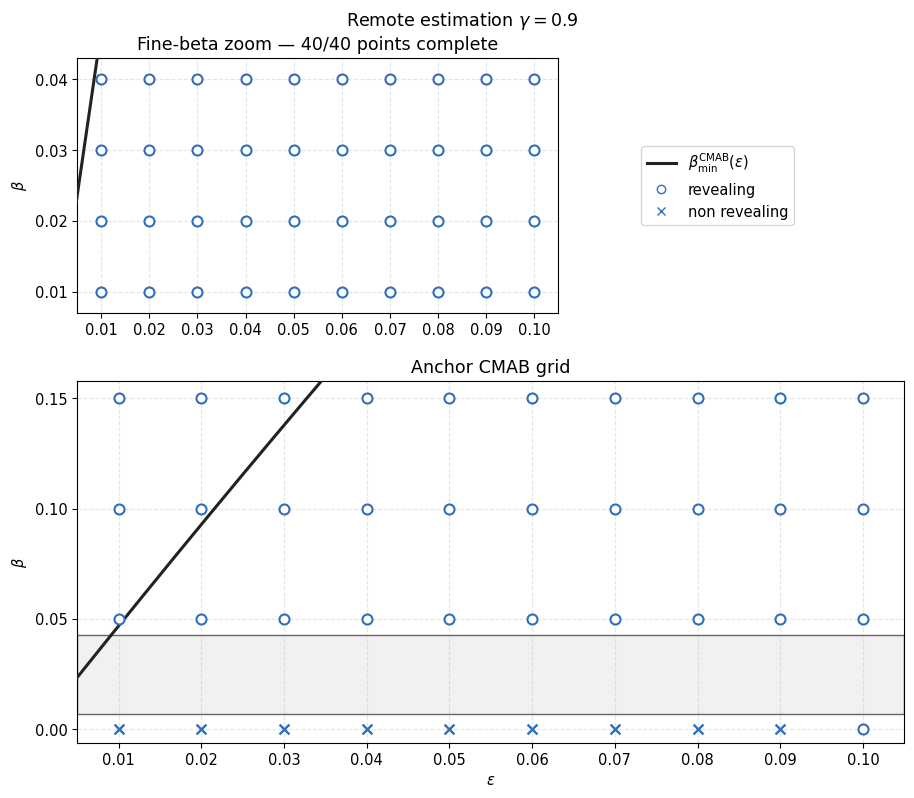

Figure saved to `experiments/jpo_exps/cmab_exps/remote_estimation_revealing_grid/plots/gamma_0p9_fullgrid_zoom.png`.

In [3]:
def beta_min(epsilon, gamma=TARGET_GAMMA):
    epsilon = np.asarray(epsilon, dtype=float)
    return gamma * epsilon * (1.0 - epsilon) / (1.0 - gamma**2)

def add_grid_points(ax, data, color='#2f6fbb'):
    if data.empty:
        return
    zero = data[~data['violating']]
    positive = data[data['violating']]
    ax.scatter(
        zero['epsilon'], zero['beta'], s=52, marker='o',
        facecolors='white', edgecolors=color, linewidths=1.5,
        alpha=1.0, zorder=4,
    )
    ax.scatter(
        positive['epsilon'], positive['beta'], s=50, marker='x',
        color=color, linewidths=1.7, alpha=1.0, zorder=5,
    )

zoom_completed = completed[completed['grid_name'] == 'zoom']
full_completed = completed[completed['grid_name'] == 'full']
epsilon_dense = np.linspace(0.0, 0.30, 1200)
zoom_xlim, zoom_ylim = (0.005, 0.105), (0.007, 0.043)

with plt.rc_context({
    'font.size': 10.5,
    'axes.grid': True,
    'grid.alpha': 0.32,
    'grid.linestyle': '--',
}):
    fig = plt.figure(figsize=(9.4, 8.1))
    grid = fig.add_gridspec(2, 2, width_ratios=[0.64, 0.36], height_ratios=[0.95, 1.35], hspace=0.22)
    ax_zoom = fig.add_subplot(grid[0, 0])
    ax_legend = fig.add_subplot(grid[0, 1])
    ax_full = fig.add_subplot(grid[1, :])
    ax_legend.axis('off')

    for ax in (ax_zoom, ax_full):
        ax.plot(epsilon_dense, beta_min(epsilon_dense), color='#222222', linewidth=2.2, zorder=3)
        ax.set_ylabel(r'$\beta$')

    add_grid_points(ax_zoom, zoom_completed)
    add_grid_points(ax_full, full_completed)
    ax_zoom.set_xlim(*zoom_xlim)
    ax_zoom.set_ylim(*zoom_ylim)
    ax_zoom.set_xticks(np.arange(0.01, 0.101, 0.01))
    ax_zoom.set_yticks(np.sort(zoom_completed['beta'].unique()))
    ax_zoom.set_title(f'Fine-beta zoom — {len(zoom_completed)}/{expected_zoom} points complete')

    ax_full.set_xlim(0.005, 0.105)
    ax_full.set_ylim(-0.006, 0.158)
    ax_full.set_xticks(np.arange(0.01, 0.101, 0.01))
    ax_full.set_yticks(np.sort(full_completed['beta'].unique()))
    ax_full.set_xlabel(r'$\epsilon$')
    ax_full.set_title('Anchor CMAB grid')
    ax_full.add_patch(Rectangle((0.005, 0.007), 0.10, 0.036, facecolor='#99999922', edgecolor='#666666'))
    if full_completed.empty:
        ax_full.text(0.5, 0.5, 'Anchor grid not available', transform=ax_full.transAxes, ha='center', va='center', fontsize=13)

    legend_handles = [
        Line2D([0], [0], color='#222222', lw=2.2, label=r'$\beta_{\min}^{\mathrm{CMAB}}(\epsilon)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='white', markeredgecolor='#2f6fbb', label='revealing'),
        Line2D([0], [0], marker='x', linestyle='None', color='#2f6fbb', label='non revealing'),
    ]
    ax_legend.legend(handles=legend_handles, loc='center left', frameon=True)
    fig.suptitle(r'Remote estimation $\gamma=0.9$', y=0.985)
    fig.subplots_adjust(left=0.09, right=0.97, bottom=0.08, top=0.925)
    output = PLOTS / 'gamma_0p9_fullgrid_zoom.png'
    fig.savefig(output, dpi=220, bbox_inches='tight')
    plt.show()

display(Markdown(f'Figure saved to `{output.relative_to(REPOSITORY_ROOT)}`.'))

## Zoom diagnostics

These panels reproduce the main diagnostics used for the non-CMAB grid: reachable violation count, discounted transmission occupancy, and the final SARSOP certificate gap.

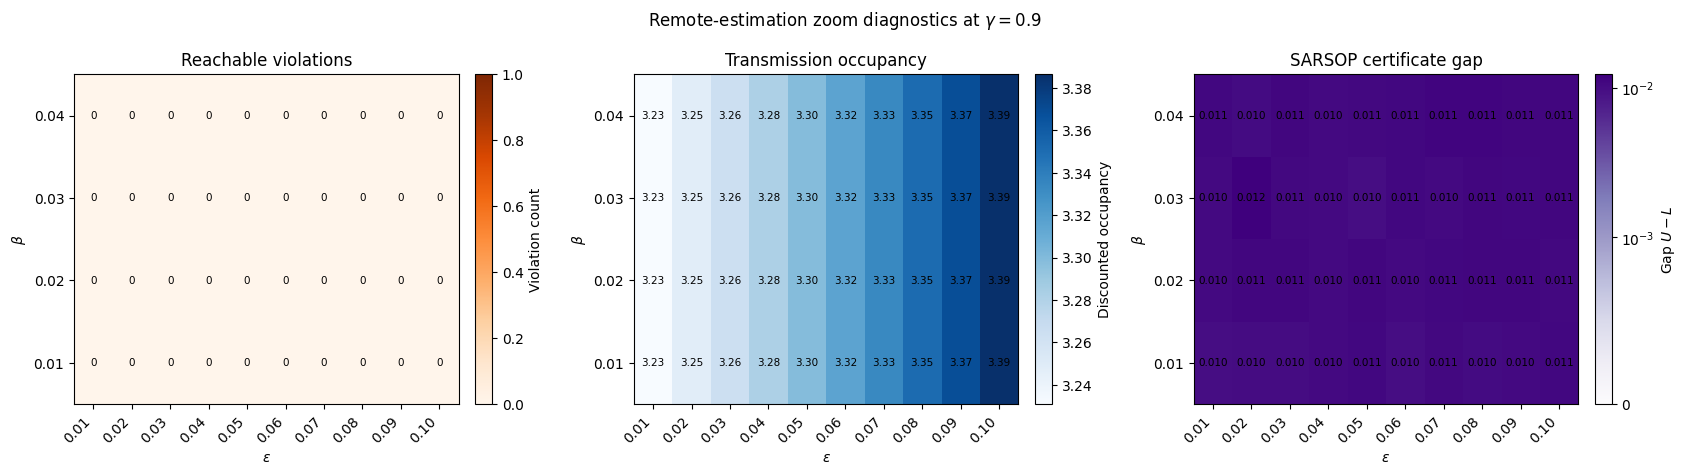

Diagnostics saved to `experiments/jpo_exps/cmab_exps/remote_estimation_revealing_grid/plots/gamma_0p9_zoom_diagnostics.png`.

In [4]:
betas = sorted(zoom_payload['experiment']['betas'])
epsilons = sorted(zoom_payload['experiment']['epsilons'])

def zoom_matrix(column):
    return zoom_completed.pivot(index='beta', columns='epsilon', values=column).reindex(index=betas, columns=epsilons)

def draw_heatmap(ax, column, title, cmap_name, norm=None, annotate=None):
    matrix = zoom_matrix(column)
    values = matrix.to_numpy(dtype=float)
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('#d9d9d9')
    image = ax.imshow(np.ma.masked_invalid(values), origin='lower', aspect='auto', cmap=cmap, norm=norm)
    if annotate is not None:
        for row, column_index in np.argwhere(np.isfinite(values)):
            ax.text(column_index, row, annotate(values[row, column_index]), ha='center', va='center', fontsize=7.5)
    ax.set_title(title)
    ax.set_xticks(range(len(epsilons)), [f'{value:.2f}' for value in epsilons], rotation=45, ha='right')
    ax.set_yticks(range(len(betas)), [f'{value:.2f}' for value in betas])
    ax.set_xlabel(r'$\epsilon$')
    ax.set_ylabel(r'$\beta$')
    return image

gap_values = zoom_matrix('sarsop_gap').to_numpy(dtype=float)
finite_gaps = gap_values[np.isfinite(gap_values)]
gap_norm = SymLogNorm(linthresh=1e-3, vmin=0.0, vmax=max(1e-3, float(finite_gaps.max())))
violation_values = zoom_matrix('violation_count').to_numpy(dtype=float)
finite_violations = violation_values[np.isfinite(violation_values)]
violation_norm = Normalize(vmin=0.0, vmax=max(1.0, float(finite_violations.max())))
tx_values = zoom_matrix('discounted_transmission_occupancy').to_numpy(dtype=float)
finite_tx = tx_values[np.isfinite(tx_values)]
tx_norm = Normalize(vmin=float(finite_tx.min()), vmax=float(finite_tx.max()))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
images = [
    draw_heatmap(axes[0], 'violation_count', 'Reachable violations', 'Oranges', norm=violation_norm, annotate=lambda value: f'{value:.0f}'),
    draw_heatmap(axes[1], 'discounted_transmission_occupancy', 'Transmission occupancy', 'Blues', norm=tx_norm, annotate=lambda value: f'{value:.2f}'),
    draw_heatmap(axes[2], 'sarsop_gap', 'SARSOP certificate gap', 'Purples', norm=gap_norm, annotate=lambda value: f'{value:.3f}'),
]
stop_matrix = zoom_completed.pivot(index='beta', columns='epsilon', values='solver_stop_reason').reindex(index=betas, columns=epsilons).to_numpy(dtype=object)
for row, column_index in np.argwhere(stop_matrix == 'max_time'):
    axes[2].add_patch(Rectangle((column_index - 0.5, row - 0.5), 1, 1, fill=False, edgecolor='#c44e52', linewidth=2.2))
for ax, image, label in zip(axes, images, ['Violation count', 'Discounted occupancy', 'Gap $U-L$']):
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label=label)
fig.suptitle(r'Remote-estimation zoom diagnostics at $\gamma=0.9$')
fig.tight_layout()
diagnostic_output = PLOTS / 'gamma_0p9_zoom_diagnostics.png'
fig.savefig(diagnostic_output, dpi=200, bbox_inches='tight')
plt.show()
display(Markdown(f'Diagnostics saved to `{diagnostic_output.relative_to(REPOSITORY_ROOT)}`.'))

## $\beta=0$: valeur et occupation des transmissions

La valeur de la politique SARSOP est comparée à celle de la politique explicite qui transmet toujours et choisit l'estimation MAP. Dans le CMAB, les transitions ne dépendent pas de l'action et cette politique constitue un benchmark optimal lorsque la communication est gratuite.

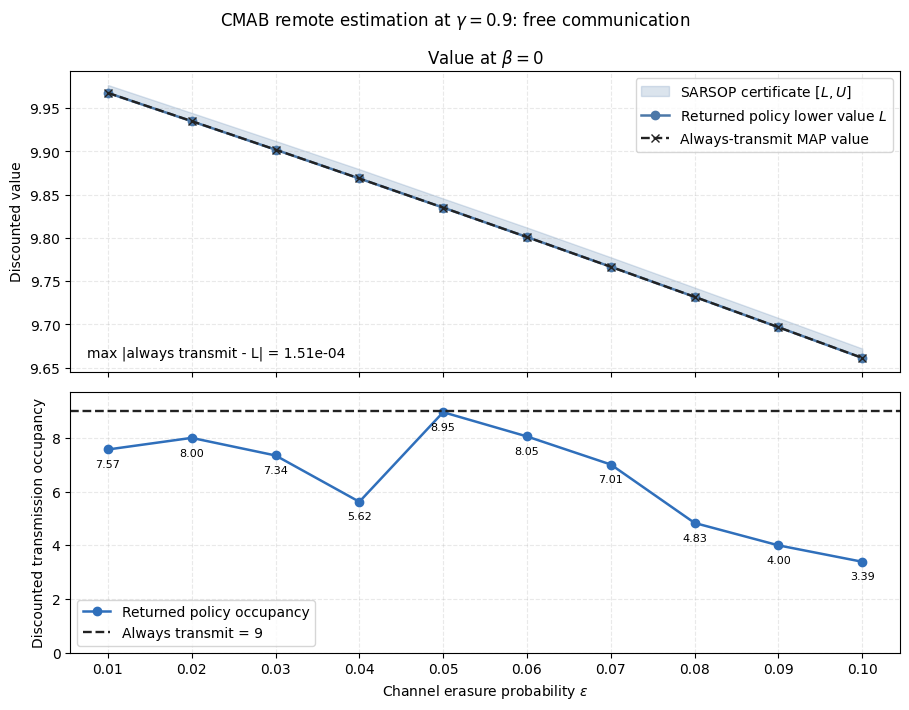

,epsilon,sarsop_lower_bound,sarsop_upper_bound,always_transmit_map_value,always_tx_minus_sarsop_lower,discounted_transmission_occupancy,normalized_transmission_rate
40,0.01,9.967671,9.976820,9.967692,2.100000e-05,7.566196,0.840688
41,0.02,9.934899,9.944580,9.935049,1.506200e-04,7.998804,0.888756
42,0.03,9.902059,9.912176,9.902069,1.008000e-05,7.343979,0.815998
43,0.04,9.868746,9.879475,9.868746,5.400000e-07,5.619173,0.624353
44,0.05,9.835075,9.845649,9.835076,8.600000e-07,8.954959,0.994995
45,0.06,9.801054,9.812070,9.801054,4.000000e-08,8.051697,0.894633
46,0.07,9.766675,9.777678,9.766675,7.000000e-08,7.006775,0.778531
47,0.08,9.731935,9.742680,9.731935,1.300000e-07,4.830581,0.536731
48,0.09,9.696829,9.707584,9.696829,2.500000e-07,3.997168,0.444130
49,0.10,9.661351,9.672182,9.661352,4.300000e-07,3.386489,0.376277


Figure saved to `experiments/jpo_exps/cmab_exps/remote_estimation_revealing_grid/plots/gamma_0p9_beta0_value_transmission.png`; always-transmit benchmark horizon: 241.

In [5]:
import sys

if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))
from mdp import create_cmab_estimation_family, select_density

beta_zero = (
    full_completed[np.isclose(full_completed['beta'], 0.0)]
    .sort_values('epsilon')
    .copy()
)
if len(beta_zero) != len(epsilons):
    raise RuntimeError('The beta=0 row is incomplete.')

cmab_family = create_cmab_estimation_family(
    n_states=full_payload['experiment']['n_states'],
    seed=full_payload['experiment']['mdp_seed'],
)
cmab_mdp = select_density(
    cmab_family, full_payload['experiment']['density'],
)
transition = cmab_mdp.P[0]
if not np.allclose(cmab_mdp.P, transition[None, :, :]):
    raise RuntimeError('The benchmark requires action-independent transitions.')

def always_transmit_map_values(epsilon_values, transition, gamma, tail_tolerance=1e-10):
    n_states = transition.shape[0]
    initial = np.full(n_states, 1.0 / n_states)
    horizon = int(np.ceil(
        np.log(tail_tolerance * (1.0 - gamma)) / np.log(gamma)
    ))
    powers = [np.eye(n_states)]
    for _ in range(1, horizon):
        powers.append(powers[-1] @ transition)
    state_distributions = [initial @ power for power in powers]
    map_scores = [power.max(axis=1) for power in powers]

    values = []
    for epsilon in epsilon_values:
        value = 0.0
        for time in range(horizon):
            # No successful message since the initially revealed state.
            stage_value = epsilon**time * float(
                initial @ map_scores[time]
            )
            # Last successful message occurred at time time - age.
            for age in range(time):
                last_success_time = time - age
                stage_value += (
                    (1.0 - epsilon)
                    * epsilon**age
                    * float(
                        state_distributions[last_success_time]
                        @ map_scores[age]
                    )
                )
            value += gamma**time * stage_value
        values.append(value)
    return np.asarray(values), horizon

epsilon_beta_zero = beta_zero['epsilon'].to_numpy(dtype=float)
always_tx_value, benchmark_horizon = always_transmit_map_values(
    epsilon_beta_zero, transition, TARGET_GAMMA,
)
beta_zero['always_transmit_map_value'] = always_tx_value
beta_zero['always_tx_minus_sarsop_lower'] = (
    beta_zero['always_transmit_map_value'] - beta_zero['sarsop_lower_bound']
)
beta_zero['normalized_transmission_rate'] = (
    (1.0 - TARGET_GAMMA) / TARGET_GAMMA
    * beta_zero['discounted_transmission_occupancy']
)

fig_beta_zero, (ax_value, ax_transmission) = plt.subplots(
    2, 1, figsize=(9.2, 7.2), sharex=True,
    gridspec_kw={'height_ratios': [1.15, 1.0]},
)

ax_value.fill_between(
    epsilon_beta_zero,
    beta_zero['sarsop_lower_bound'].to_numpy(dtype=float),
    beta_zero['sarsop_upper_bound'].to_numpy(dtype=float),
    color='#4c78a8', alpha=0.20, label='SARSOP certificate $[L,U]$',
)
ax_value.plot(
    epsilon_beta_zero, beta_zero['sarsop_lower_bound'],
    color='#4c78a8', marker='o', linewidth=1.8,
    label='Returned policy lower value $L$',
)
ax_value.plot(
    epsilon_beta_zero, beta_zero['always_transmit_map_value'],
    color='#222222', marker='x', linestyle='--', linewidth=1.7,
    label='Always-transmit MAP value',
)
ax_value.set_ylabel('Discounted value')
ax_value.set_title(r'Value at $\beta=0$')
ax_value.grid(True, alpha=0.28, linestyle='--')
ax_value.legend(loc='best')
maximum_value_difference = float(
    beta_zero['always_tx_minus_sarsop_lower'].abs().max()
)
ax_value.text(
    0.02, 0.05,
    f'max |always transmit - L| = {maximum_value_difference:.2e}',
    transform=ax_value.transAxes,
)

maximum_occupancy = TARGET_GAMMA / (1.0 - TARGET_GAMMA)
ax_transmission.plot(
    epsilon_beta_zero,
    beta_zero['discounted_transmission_occupancy'],
    color='#2f6fbb', marker='o', linewidth=1.8,
    label='Returned policy occupancy',
)
ax_transmission.axhline(
    maximum_occupancy, color='#222222', linestyle='--', linewidth=1.7,
    label=f'Always transmit = {maximum_occupancy:.0f}',
)
for epsilon, occupancy in zip(
    epsilon_beta_zero, beta_zero['discounted_transmission_occupancy'],
):
    ax_transmission.annotate(
        f'{occupancy:.2f}', (epsilon, occupancy),
        xytext=(0, -13), textcoords='offset points',
        ha='center', fontsize=8,
    )
ax_transmission.set_ylim(0.0, maximum_occupancy * 1.08)
ax_transmission.set_ylabel('Discounted transmission occupancy')
ax_transmission.set_xlabel(r'Channel erasure probability $\epsilon$')
ax_transmission.set_xticks(
    epsilon_beta_zero,
    [f'{value:.2f}' for value in epsilon_beta_zero],
)
ax_transmission.grid(True, alpha=0.28, linestyle='--')
ax_transmission.legend(loc='lower left')

fig_beta_zero.suptitle(
    r'CMAB remote estimation at $\gamma=0.9$: free communication'
)
fig_beta_zero.tight_layout()
beta_zero_output = PLOTS / 'gamma_0p9_beta0_value_transmission.png'
fig_beta_zero.savefig(beta_zero_output, dpi=210, bbox_inches='tight')
plt.show()

display(beta_zero[[
    'epsilon', 'sarsop_lower_bound', 'sarsop_upper_bound',
    'always_transmit_map_value', 'always_tx_minus_sarsop_lower',
    'discounted_transmission_occupancy', 'normalized_transmission_rate',
]].round(8))
display(Markdown(
    f'Figure saved to `{beta_zero_output.relative_to(REPOSITORY_ROOT)}`; '
    f'always-transmit benchmark horizon: {benchmark_horizon}.'
))